## Imports

In [2]:
# from google.colab import drive
# drive.mount('/content/drive')

In [3]:
import warnings
warnings.filterwarnings("ignore")

In [30]:
import nltk
nltk.download('stopwords')
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from concurrent.futures import ThreadPoolExecutor, as_completed

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [20]:
from sentence_transformers import SentenceTransformer
from transformers import logging as transformers_logging

# Set transformers logging level to error to suppress all but error messages
transformers_logging.set_verbosity_error()

In [21]:
# read train and test data
train_data = pd.read_json("train.json")

In [22]:
print("Train Data Columns:", train_data.columns)

Train Data Columns: Index(['person_data', 'doctor_data', 'patient_name', 'address', 'phone',
       'gender', 'age', 'dob', 'doctor_name', 'full_patient_data',
       'health_problem', 'patient_convo', 'soap_notes'],
      dtype='object')


In [53]:
## random 100 samples from train_data
convo_soap_data = train_data[['patient_convo', 'soap_notes']]
convo_soap_data = convo_soap_data.sample(n=100, random_state=42)
convo_soap_data.reset_index(drop=True, inplace=True)

## Preprocessing

In [54]:
# implement multi threading for preprocessing
def preprocess_text(text):
    """Preprocess text by lowercasing, removing punctuation, and removing stop words.
    """
    text = text.lower()
    text = ''.join([char for char in text if char.isalnum() or char.isspace()])
    stop_words = set(nltk.corpus.stopwords.words('english'))
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text

In [55]:
convo_soap_data['cleaned_patient_convo'] = convo_soap_data['patient_convo'].apply(preprocess_text)
convo_soap_data['cleaned_soap_notes'] = convo_soap_data['soap_notes'].apply(preprocess_text)
convo_soap_data.head(2)

,patient_convo,soap_notes,cleaned_patient_convo,cleaned_soap_notes
0,"\nPhysician: Good morning, Mr. Long. How are y...",Subjective:\nMr. Long reports feeling tired la...,physician good morning mr long feeling today p...,subjective mr long reports feeling tired latel...
1,"\n\n\nPhysician: Good morning, Cathy. It's bee...",Subjective:\nCathy Bryant reports experiencing...,physician good morning cathy since last visit ...,subjective cathy bryant reports experiencing t...


## Cosine Similarity

In [56]:
## benchmark evaluation - similarity score using text embedding models
def compute_similarity_score(patient_convo, soap_notes):
    model = SentenceTransformer('all-MiniLM-L6-v2')
    convo_embedding = model.encode(patient_convo)
    soap_embedding = model.encode(soap_notes)
    similarity_score = cosine_similarity([convo_embedding], [soap_embedding])[0][0]
    return similarity_score

In [58]:
import time
from tqdm.notebook import tqdm

# Initialize a list to store similarity scores
similarity_scores = []

start_time = time.time()

# Use ThreadPoolExecutor for parallel processing
with ThreadPoolExecutor(max_workers=None) as executor: # max_workers=None uses a default based on CPU cores
    # Submit tasks and track progress with tqdm
    futures = [executor.submit(compute_similarity_score, row['cleaned_patient_convo'], row['cleaned_soap_notes'])
               for index, row in convo_soap_data.iterrows()]

    for future in tqdm(as_completed(futures), total=len(futures), desc="Calculating Similarity Scores"):
        similarity_scores.append(future.result())

end_time = time.time()

convo_soap_data['similarity_score'] = similarity_scores

print(f"Elapsed time: {end_time - start_time:.2f} seconds")
display(convo_soap_data.head(2))

Calculating Similarity Scores:   0%|          | 0/100 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Elapsed time: 188.59 seconds


,patient_convo,soap_notes,cleaned_patient_convo,cleaned_soap_notes,similarity_score
0,"\nPhysician: Good morning, Mr. Long. How are y...",Subjective:\nMr. Long reports feeling tired la...,physician good morning mr long feeling today p...,subjective mr long reports feeling tired latel...,0.539931
1,"\n\n\nPhysician: Good morning, Cathy. It's bee...",Subjective:\nCathy Bryant reports experiencing...,physician good morning cathy since last visit ...,subjective cathy bryant reports experiencing t...,0.831572


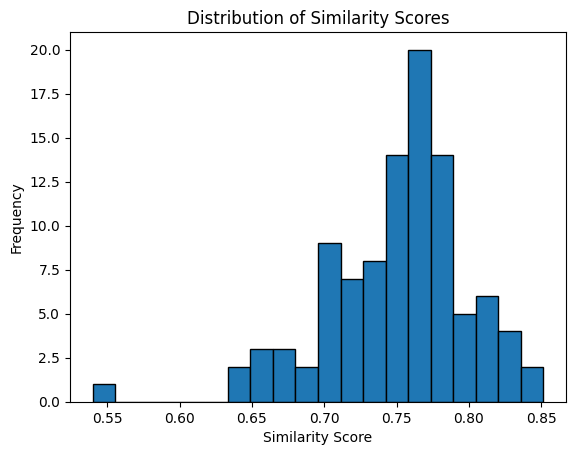

In [62]:
## visualize similarity scores distribution
import matplotlib.pyplot as plt
plt.hist(convo_soap_data['similarity_score'], bins=20, edgecolor='black')
plt.title('Distribution of Similarity Scores')
plt.xlabel('Similarity Score')
plt.ylabel('Frequency')
plt.show()

In [64]:
# pull records with similarity score < 0.6
low_similarity_records = convo_soap_data[convo_soap_data['similarity_score'] < 0.6]
print("Low Similarity Records:")
print(low_similarity_records[['cleaned_patient_convo', 'cleaned_soap_notes', 'similarity_score']])

Low Similarity Records:
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                

In [90]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 1000)

In [66]:
print("Complete Record at Index 0:")
print(convo_soap_data['cleaned_patient_convo'].loc[0])

Complete Record at Index 0:
physician good morning mr long feeling today patient bad doctor ive feeling pretty tired lately though wife says snore lot sometimes stop breathing sleep physician see noticed symptoms patient yeah ive trouble concentrating work sometimes feel like im going fall asleep desk blood sugar pretty high lately even though ive trying eat healthier physician okay thats helpful know tell sleep habits typically sleep side back stomach patient usually sleep back lately ive trying sleep side wife says might help snoring physician thats good idea noticed improvement since started sleeping side patient really doctor still feel pretty tired day sometimes wake headache physician see experienced symptoms might related sleep difficulty staying asleep waking frequently night patient yeah wake lot night use bathroom sometimes trouble falling back asleep physician okay thats helpful know tell daytime sleepiness affecting ability function work perform daily activities patient yea

In [67]:
print("Complete Record at Index 0:")
print(convo_soap_data['cleaned_soap_notes'].loc[0])

Complete Record at Index 0:
subjective mr long reports feeling tired lately experiencing excessive daytime sleepiness mentions wife observed snoring loudly gasping air sleep also notes trouble concentrating work high blood sugar levels despite efforts eat healthier mr long states typically sleeps back trying sleep side alleviate snoring objective examination mr long appears fatigued alert demonstrates signs respiratory distress blood pressure within normal limits blood sugar levels elevated mr long mentions waking frequently night use bathroom experiencing morning headaches dry mouth sore throat assessment mr long presents symptoms consistent obstructive sleep apnea including excessive daytime sleepiness snoring morning headaches recent sleep study revealed moderate apneahypopnea index 20 additionally blood sugar levels remain elevated despite efforts improve diet plan refer mr long sleep specialist dr elizabeth thompson evaluation initiation continuous positive airway pressure cpap th

In [87]:
pd.reset_option('display.max_columns')
pd.reset_option('display.max_colwidth')
pd.reset_option('display.max_rows')

## Bert Score

In [68]:
!pip install bert_score

In [76]:
import logging
from bert_score import score
from transformers import logging as transformers_logging

# Set transformers logging level to error to suppress all but error messages
transformers_logging.set_verbosity_error()
def compute_bert_score(cleaned_patient_convo, cleaned_soap_notes):
    P, R, F1 = score([cleaned_patient_convo], [cleaned_soap_notes], lang='en', verbose=False)
    return F1.item()

In [78]:
import time
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.notebook import tqdm

bert_scores = []

start_time_bert = time.time()

with ThreadPoolExecutor(max_workers=None) as executor:
    futures_bert = [
        executor.submit(compute_bert_score, row['cleaned_patient_convo'], row['cleaned_soap_notes'])
        for index, row in convo_soap_data.iterrows()
    ]

    for future in tqdm(as_completed(futures_bert), total=len(futures_bert), desc="Calculating BERT Scores"):
        bert_scores.append(future.result())

end_time_bert = time.time()

convo_soap_data['bert_score'] = bert_scores

print(f"Elapsed time for BERT score calculation: {end_time_bert - start_time_bert:.2f} seconds")
display(convo_soap_data.head())

Calculating BERT Scores:   0%|          | 0/100 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

Elapsed time for BERT score calculation: 754.97 seconds


,patient_convo,soap_notes,cleaned_patient_convo,cleaned_soap_notes,similarity_score,bert_score
0,"\nPhysician: Good morning, Mr. Long. How are you feeling today?\n\nPatient: Not too bad, doctor. I've been feeling pretty tired lately, though. And my wife says I snore a lot and sometimes stop breathing during sleep.\n\nPhysician: I see. Have you noticed any other symptoms?\n\nPatient: Yeah, I've been having trouble concentrating at work, and sometimes I feel like I'm going to fall asleep at my desk. And my blood sugar has been pretty high lately, even though I've been trying to eat healthier.\n\nPhysician: Okay, that's helpful to know. Can you tell me more about your sleep habits? Do you typically sleep on your side, back, or stomach?\n\nPatient: I usually sleep on my back. But lately, I've been trying to sleep on my side because my wife says it might help with the snoring.\n\nPhysician: That's a good idea. Have you noticed any improvement since you started sleeping on your side?\n\nPatient: Not really, doctor. I still feel pretty tired during the day. And sometimes I wake up with a headache.\n\nPhysician: I see. Have you experienced any other symptoms that might be related to your sleep, such as difficulty staying asleep or waking up frequently during the night?\n\nPatient: Yeah, I wake up a lot during the night to use the bathroom. And sometimes I have trouble falling back asleep after that.\n\nPhysician: Okay, that's helpful to know. Can you tell me more about your daytime sleepiness? Is it affecting your ability to function at work or perform daily activities?\n\nPatient: Yeah, it's definitely affecting my work. I've been having trouble staying focused and sometimes miss important details. And I've been feeling pretty irritable lately, which isn't like me.\n\nPhysician: I understand. Have you noticed any other symptoms that might be related to your sleep apnea, such as morning headaches, dry mouth, or sore throat?\n\nPatient: Yeah, I do get pretty bad headaches in the morning. And sometimes my throat feels dry and sore.\n\nPhysician: Okay, that's helpful to know. Have you had any recent changes in your work schedule or stress levels that might be affecting your sleep?\n\nPatient: Well, I did start a new job a few months ago, and it's been pretty stressful. But I don't know if that's related to my sleep problems.\n\nPhysician: It's possible that the stress could be contributing to your sleep issues. Have you tried any stress-reducing techniques, such as meditation or deep breathing exercises?\n\nPatient: Not really, doctor. I've been meaning to try some relaxation techniques, but I haven't gotten around to it yet.\n\nPhysician: That's something we can discuss further. In the meantime, I'd like to refer you to a sleep specialist to get a better understanding of your sleep apnea and determine the best course of treatment. And we'll also schedule some follow-up appointments to monitor your blood sugar and blood pressure. Does that sound good to you?\n\nPatient: Yeah, that sounds great, doctor. Thank you for your help.","Subjective:\nMr. Long reports feeling tired lately and experiencing excessive daytime sleepiness. He mentions that his wife has observed him snoring loudly and gasping for air during sleep. He also notes trouble concentrating at work and high blood sugar levels despite efforts to eat healthier. Mr. Long states that he typically sleeps on his back but has been trying to sleep on his side to alleviate snoring.\n\nObjective:\nDuring the examination, Mr. Long appears fatigued but alert. He demonstrates no signs of respiratory distress. His blood pressure is within normal limits, and his blood sugar levels are elevated. Mr. Long mentions waking up frequently during the night to use the bathroom and experiencing morning headaches, dry mouth, and a sore throat.\n\nAssessment:\nMr. Long presents with symptoms consistent with obstructive sleep apnea, including excessive daytime sleepiness, snoring, and morning headaches. 

In [80]:
convo_soap_data.shape

(100, 6)

In [81]:
#save csv
convo_soap_data.to_csv("train_sample_bert_cosine_score.csv", index=False)


## ROUGE

In [44]:
!pip install rouge_score

  Preparing metadata (setup.py) ... done
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=e967921540944dae719ebc0fdeb1dd24849a31393ef5a15a39942969da9b2d69
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge_score


In [82]:
from rouge_score import rouge_scorer
import time
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.notebook import tqdm

def compute_rouge_scores(patient_convo, soap_notes):
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    scores = scorer.score(patient_convo, soap_notes)
    return {
        'rouge1_fmeasure': scores['rouge1'].fmeasure,
        'rouge2_fmeasure': scores['rouge2'].fmeasure,
        'rougel_fmeasure': scores['rougeL'].fmeasure
    }

In [83]:
pd.reset_option('display.max_columns')
pd.reset_option('display.max_colwidth')
pd.reset_option('display.max_rows')

In [84]:
rouge_scores_list = []

start_time_rouge = time.time()

with ThreadPoolExecutor(max_workers=None) as executor:
    futures_rouge = [
        executor.submit(compute_rouge_scores, row['patient_convo'], row['soap_notes'])
        for index, row in convo_soap_data.iterrows()
    ]

    for future in tqdm(as_completed(futures_rouge), total=len(futures_rouge), desc="Calculating ROUGE Scores"):
        rouge_scores_list.append(future.result())

end_time_rouge = time.time()

# Convert list of dictionaries to a DataFrame
rouge_scores_df = pd.DataFrame(rouge_scores_list)

# Concatenate the new scores to the original DataFrame
convo_soap_data = pd.concat([convo_soap_data, rouge_scores_df], axis=1)

print(f"Elapsed time for ROUGE score calculation: {end_time_rouge - start_time_rouge:.2f} seconds")
display(rouge_scores_df.head())

Calculating ROUGE Scores:   0%|          | 0/100 [00:00<?, ?it/s]

Elapsed time for ROUGE score calculation: 6.32 seconds


,rouge1_fmeasure,rouge2_fmeasure,rougel_fmeasure
0,0.315789,0.108254,0.202429
1,0.404848,0.148238,0.240000
2,0.403385,0.141443,0.197461
3,0.383266,0.148850,0.226721
4,0.367876,0.119481,0.202073


In [85]:
convo_soap_data.shape

(100, 9)

In [86]:
convo_soap_data.head()

,patient_convo,soap_notes,cleaned_patient_convo,cleaned_soap_notes,similarity_score,bert_score,rouge1_fmeasure,rouge2_fmeasure,rougel_fmeasure
0,"\nPhysician: Good morning, Mr. Long. How are y...",Subjective:\nMr. Long reports feeling tired la...,physician good morning mr long feeling today p...,subjective mr long reports feeling tired latel...,0.539931,0.836363,0.315789,0.108254,0.202429
1,"\n\n\nPhysician: Good morning, Cathy. It's bee...",Subjective:\nCathy Bryant reports experiencing...,physician good morning cathy since last visit ...,subjective cathy bryant reports experiencing t...,0.831572,0.825978,0.404848,0.148238,0.240000
2,"\nPhysician: Good morning, Mildred. How are yo...",SOAP Note:\n\nSubjective:\nMildred Gordon repo...,physician good morning mildred feeling today p...,soap note subjective mildred gordon reports ex...,0.727471,0.814810,0.403385,0.141443,0.197461
3,"\n\nPhysician: Good morning, Tina. How are you...","Subjective:\nTina Henderson, a 56-year-old fem...",physician good morning tina feeling today pati...,subjective tina henderson 56yearold female rep...,0.749871,0.822288,0.383266,0.148850,0.226721
4,"\n\nPhysician: Good morning, Mr. Ruiz. How are...",Subjective:\nMr. Ruiz reports feeling tired an...,physician good morning mr ruiz feeling today p...,subjective mr ruiz reports feeling tired thirs...,0.732913,0.792277,0.367876,0.119481,0.202073


In [88]:
#save csv
convo_soap_data.to_csv("train_sample_bert_cosine_rouge_score.csv", index=False)


## testing

In [113]:
print(convo_soap_data['patient_convo'].loc[2])

physician good morning mildred feeling today patient good morning doctor ive feeling pretty good lately experiencing issues allergies physician see elaborate symptoms first notice affecting patient well ive runny nose itchy eyes past weeks worse im home especially bedroom ive also feeling bit congested sinus pressure physician understand noticed patterns triggers seem make symptoms worse patient yes definitely seems get worse im around dust pollen ive trying avoid things much possible hard avoid completely physician thats understandable experienced shortness breath wheezing patient yes bit mostly exert like im walking chores around house physician see noticed symptoms coughing chest tightness patient yes ive bit cough especially night sometimes feel like theres band around chest like hard breathe deeply physician understand recent changes environment routine could contributing symptoms patient well get new cat months ago could trigger physician possible cats definitely cause allergic r

In [112]:
print(convo_soap_data['soap_notes'].loc[2])

soap note subjective mildred gordon reports experiencing symptoms respiratory allergies including runny nose itchy eyes congestion sinus pressure shortness breath wheezing coughing chest tightness sneezing postnasal drip headaches fatigue trouble sleeping changes appetite also expresses concerns effectiveness current inhaler medications objective examination mildred appeared wellgroomed alert exhibited signs respiratory distress including coughing mucus chest pain vital signs within normal limits medication adherence confirmed mildreds inhaler technique assessed assessment mildred gordon presents symptoms consistent respiratory allergies asthma exacerbation concerns regarding adequacy current medication regimen managing symptoms effectively evaluation allergy test warranted identify specific triggers lifestyle modifications potential medication adjustments may necessary plan 1 schedule allergy test identify specific triggers mildreds respiratory allergies 2 review potentially adjust mi